# Simplify News Pipeline
Notebook-first workflow for the CS5246 project.

This notebook runs EDA, generates S0-S3 outputs, evaluates them, and saves report-ready files.

## 0. Dataset bootstrap
This notebook first ensures that a local CSV dataset exists. If `./data/` is empty, it downloads CNN/DailyMail and saves `train.csv`, `validation.csv`, and `test.csv`.


In [7]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.config import DEFAULT_CONFIG, Paths
from src.dataset_bootstrap import ensure_dataset
from src.io_utils import ensure_dirs, load_default_dataset, standardize_dataframe
from src.pipeline import generate_system_outputs
from src.preprocess import split_sentences, tokenize

paths = Paths(root=ROOT, data_dir=ROOT / 'data', output_dir=ROOT / 'outputs', figure_dir=ROOT / 'outputs/figures', table_dir=ROOT / 'outputs/tables', sample_dir=ROOT / 'outputs/samples')
ensure_dirs(paths.data_dir, paths.output_dir, paths.figure_dir, paths.table_dir, paths.sample_dir)

# Set force_download=True to refresh the local CSV files.
dataset_status = ensure_dataset(
    data_dir=paths.data_dir,
    auto_download=True,
    force_download=False,
)
print(dataset_status)

raw_df, colmap, source_path = load_default_dataset(paths.data_dir)
df = standardize_dataframe(raw_df, colmap)
print(f"Loaded dataset from: {source_path}")
df.head(3)



Found existing local CSV dataset.
Loaded dataset from: /Users/yashmishra/Downloads/cs5246-project/cs5246_simple_news/data/train.csv


,doc_id,title,article,reference
0,0,,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...
1,1,,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...
2,2,,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa..."


## 1. EDA

In [9]:
# eda = df.copy()
# eda['article_word_count'] = eda['article'].apply(lambda x: len(tokenize(x)))
# eda['article_sentence_count'] = eda['article'].apply(lambda x: len(split_sentences(x)))
# eda['reference_word_count'] = eda['reference'].apply(lambda x: len(tokenize(x)))
# eda_summary = pd.DataFrame({
#     'metric': ['num_documents', 'avg_article_words', 'median_article_words', 'avg_article_sentences', 'avg_reference_words'],
#     'value': [len(eda), eda['article_word_count'].mean(), eda['article_word_count'].median(), eda['article_sentence_count'].mean(), eda['reference_word_count'].mean()]
# })
# eda_summary.to_csv(paths.table_dir / 'eda_summary.csv', index=False)
# eda_summary

MAX_DOCS = 2000
if MAX_DOCS is not None:
    df = df.head(MAX_DOCS).copy()

eda = df[['article', 'reference']].copy()
if len(eda) > 1000:
    eda = eda.sample(1000, random_state=42).reset_index(drop=True)

eda['article_word_count'] = eda['article'].str.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+(?:,\d+)*(?:\.\d+)?").str.len()
eda['article_sentence_count'] = eda['article'].str.count(r'[.!?]+')
eda['reference_word_count'] = eda['reference'].str.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+(?:,\d+)*(?:\.\d+)?").str.len()

eda_summary = pd.DataFrame({
    'metric': ['num_documents_in_run', 'num_documents_in_eda', 'avg_article_words', 'median_article_words', 'avg_article_sentences', 'avg_reference_words'],
    'value': [len(df), len(eda), eda['article_word_count'].mean(), eda['article_word_count'].median(), eda['article_sentence_count'].mean(), eda['reference_word_count'].mean()]
})
eda_summary

,metric,value
0,num_documents_in_run,2000.000
1,num_documents_in_eda,1000.000
2,avg_article_words,606.685
3,median_article_words,567.000
4,avg_article_sentences,37.079
5,avg_reference_words,40.569


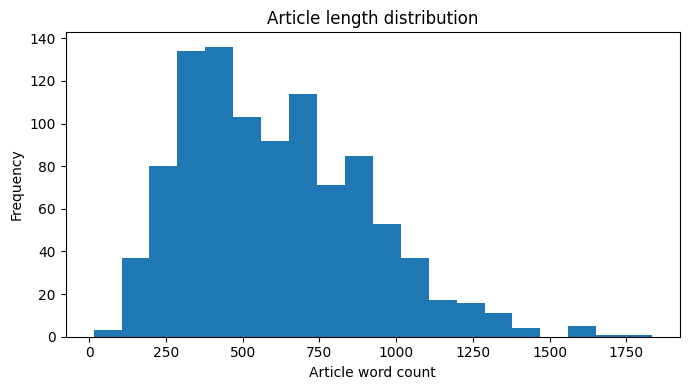

In [10]:
plt.figure(figsize=(7,4))
plt.hist(eda['article_word_count'], bins=min(20, max(5, len(eda))))
plt.xlabel('Article word count')
plt.ylabel('Frequency')
plt.title('Article length distribution')
plt.tight_layout()
plt.savefig(paths.figure_dir / 'article_length_distribution.png', dpi=180)
plt.show()

## 2. Run systems

In [11]:
run_df = df.copy()
if len(run_df) > DEFAULT_CONFIG.sample_size:
    run_df = run_df.iloc[:DEFAULT_CONFIG.sample_size].copy()
outputs = generate_system_outputs(run_df, DEFAULT_CONFIG)
outputs.to_csv(paths.output_dir / 'all_system_outputs.csv', index=False)
outputs[['doc_id', 'system_label', 'rouge1', 'rougel', 'flesch_reading_ease', 'fkgl', 'entity_coverage', 'number_coverage', 'date_coverage']].head(12)

,doc_id,system_label,rouge1,rougel,flesch_reading_ease,fkgl,entity_coverage,number_coverage,date_coverage
0,0,S0 Lead-3,0.342105,0.315789,52.149831,12.879347,0.243243,0.600000,0.0
1,0,S1 TextRank,0.342105,0.315789,52.149831,12.879347,0.243243,0.600000,0.0
2,0,S2 Coverage-aware TextRank,0.329114,0.316456,56.545538,11.185573,0.297297,0.600000,0.0
3,0,S3 Coverage-aware + simplification,0.329114,0.316456,56.545538,11.185573,0.297297,0.600000,0.0
4,1,S0 Lead-3,0.361905,0.152381,44.917401,11.880000,0.257143,0.000000,0.0
5,1,S1 TextRank,0.233010,0.135922,67.931667,8.255926,0.114286,0.166667,0.0
6,1,S2 Coverage-aware TextRank,0.347826,0.144928,57.905000,9.654444,0.200000,0.166667,0.0
7,1,S3 Coverage-aware + simplification,0.347826,0.144928,57.905000,9.654444,0.200000,0.166667,0.0
8,2,S0 Lead-3,0.319149,0.234043,53.556471,10.012549,0.176471,0.333333,1.0
9,2,S1 TextRank,0.186047,0.139535,71.311667,10.600000,0.147059,0.000000,1.0


## 3. Aggregate metrics

In [13]:
summary = outputs.groupby(['system', 'system_label']).mean(numeric_only=True).reset_index()
summary.to_csv(paths.table_dir / 'system_metrics_summary.csv', index=False)
summary

,system,system_label,doc_id,rouge1,rouge2,rougel,word_count,sentence_count,avg_sentence_len,flesch_reading_ease,fkgl,entity_coverage,number_coverage,date_coverage,novel_token_ratio
0,s0_lead3,S0 Lead-3,99.5,0.307692,0.122792,0.205127,63.795,3.625,18.741225,48.574963,11.139938,0.216406,0.194110,0.241178,0.000000
1,s1_textrank,S1 TextRank,99.5,0.275600,0.094292,0.187850,79.380,3.935,21.262883,50.293623,11.526670,0.224793,0.186435,0.242672,0.000000
2,s2_coverage,S2 Coverage-aware TextRank,99.5,0.259545,0.093779,0.177138,105.660,5.315,20.918617,50.691799,11.385607,0.281595,0.289005,0.312539,0.000000
3,s3_simplified,S3 Coverage-aware + simplification,99.5,0.259199,0.093476,0.176791,105.660,5.315,20.918617,51.071980,11.332579,0.281595,0.289005,0.312539,0.000934


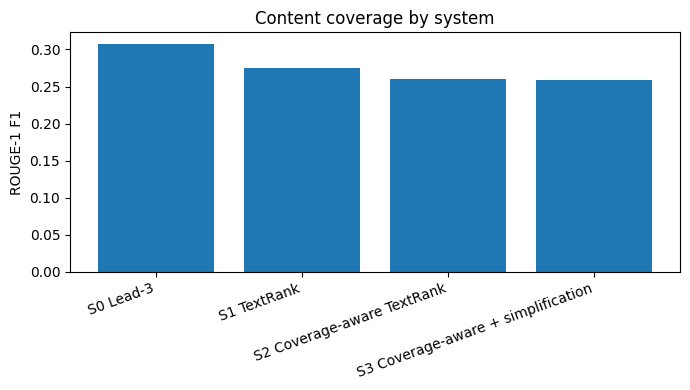

In [14]:
plt.figure(figsize=(7,4))
plt.bar(summary['system_label'], summary['rouge1'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('ROUGE-1 F1')
plt.title('Content coverage by system')
plt.tight_layout()
plt.savefig(paths.figure_dir / 'rouge1_by_system.png', dpi=180)
plt.show()

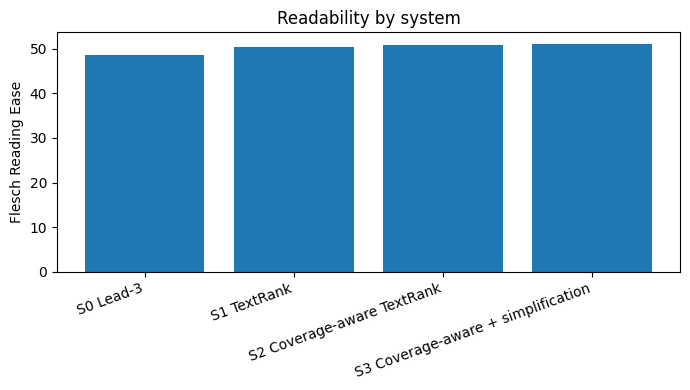

In [15]:
plt.figure(figsize=(7,4))
plt.bar(summary['system_label'], summary['flesch_reading_ease'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('Flesch Reading Ease')
plt.title('Readability by system')
plt.tight_layout()
plt.savefig(paths.figure_dir / 'readability_by_system.png', dpi=180)
plt.show()

## 4. Qualitative samples

In [16]:
sample_docs = outputs['doc_id'].drop_duplicates().tolist()[:3]
qual_rows = outputs[outputs['doc_id'].isin(sample_docs)].copy()
qual_rows[['doc_id', 'system_label', 'title', 'output', 'glossary']].to_csv(paths.sample_dir / 'qualitative_samples.csv', index=False)
qual_rows[['doc_id', 'system_label', 'title', 'output', 'glossary']]

,doc_id,system_label,title,output,glossary
0,0,S0 Lead-3,,"LONDON, England (Reuters) -- Harry Potter star...",[]
1,0,S1 TextRank,,"LONDON, England (Reuters) -- Harry Potter star...",[]
2,0,S2 Coverage-aware TextRank,,"LONDON, England (Reuters) -- Harry Potter star...",[]
3,0,S3 Coverage-aware + simplification,,"LONDON, England (Reuters) -- Harry Potter star...",[]
4,1,S0 Lead-3,,Editor's note: In our Behind the Scenes series...,[]
5,1,S1 TextRank,,Leifman says about one-third of all people in ...,[]
6,1,S2 Coverage-aware TextRank,,"MIAMI, Florida (CNN) -- The ninth floor of the...",[]
7,1,S3 Coverage-aware + simplification,,"MIAMI, Florida (CNN) -- The ninth floor of the...",[]
8,2,S0 Lead-3,,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...",[]
9,2,S1 TextRank,,"""The whole bridge from one side of the Mississ...",[]


## 5. Files produced
- `outputs/all_system_outputs.csv`
- `outputs/tables/eda_summary.csv`
- `outputs/tables/system_metrics_summary.csv`
- `outputs/samples/qualitative_samples.csv`
- `outputs/figures/article_length_distribution.png`
- `outputs/figures/rouge1_by_system.png`
- `outputs/figures/readability_by_system.png`